In [1]:
import pandas as pd

In [4]:
df = pd.read_csv("diabetes_Modified.csv")

In [5]:
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Glucose                   768 non-null    int64  
 1   BloodPressure             768 non-null    int64  
 2   SkinThickness             768 non-null    int64  
 3   Insulin                   768 non-null    int64  
 4   BMI                       768 non-null    float64
 5   DiabetesPedigreeFunction  768 non-null    float64
 6   Age                       768 non-null    int64  
 7   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 48.1 KB


In [7]:
X = df.drop("Outcome",axis=1) #predictors
Y = df["Outcome"]  #target

In [9]:

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X, Y,test_size=0.20,random_state=0)

In [18]:
%%time
from sklearn.linear_model import LogisticRegression
logistic_regression1 = LogisticRegression(solver="liblinear", random_state=10)
model1 = logistic_regression1.fit(X_train, Y_train)

CPU times: user 5.99 ms, sys: 997 µs, total: 6.99 ms
Wall time: 7.91 ms


In [11]:
from sklearn import metrics
from sklearn.metrics import confusion_matrix

In [21]:
Y_pred_train = model1.predict(X_train)

In [23]:
con_mat = confusion_matrix(Y_train,Y_pred_train)
print(con_mat)
print("Accuracy: ",metrics.accuracy_score(Y_train,Y_pred_train))
print('Precision: ',metrics.precision_score(Y_train,Y_pred_train))
print('Recall score: ',metrics.recall_score(Y_train,Y_pred_train))
print('F1 score: ',metrics.f1_score(Y_train,Y_pred_train))

[[351  42]
 [ 99 122]]
Accuracy:  0.7703583061889251
Precision:  0.7439024390243902
Recall score:  0.5520361990950227
F1 score:  0.6337662337662338


In [26]:
probablities = model1.predict_proba(X_train)
positive_probablity = probablities[:,1]
positive_probablity

array([0.68095031, 0.17671653, 0.60734416, 0.22943805, 0.58508929,
       0.90341964, 0.56826115, 0.74243512, 0.06843218, 0.31774262,
       0.71911039, 0.52045185, 0.16223769, 0.1937408 , 0.3073876 ,
       0.19088134, 0.24152833, 0.20920539, 0.19064228, 0.32200425,
       0.58705769, 0.16175022, 0.36255489, 0.13759176, 0.16190373,
       0.13279657, 0.17188362, 0.55340117, 0.19624085, 0.9079579 ,
       0.44799619, 0.05544613, 0.75258901, 0.25825836, 0.47463404,
       0.20343842, 0.30332979, 0.13838505, 0.10766864, 0.31421932,
       0.15217793, 0.62660225, 0.60942782, 0.46109809, 0.14366327,
       0.27439821, 0.13988545, 0.23169207, 0.2347995 , 0.37642943,
       0.3103113 , 0.22723716, 0.24013268, 0.24001683, 0.41341896,
       0.21755148, 0.16582584, 0.14872049, 0.35232111, 0.37868906,
       0.26217289, 0.30093523, 0.4376943 , 0.38432183, 0.69193629,
       0.27275813, 0.18096844, 0.1129161 , 0.4834587 , 0.56021181,
       0.57563557, 0.51532126, 0.25722351, 0.22810476, 0.11766

In [29]:
custom_thres = 0.4
y_pred_train_2 = (positive_probablity>=custom_thres).astype(int)

print(confusion_matrix(Y_train, y_pred_train_2))
print("Accuracy: ",metrics.accuracy_score(Y_train,y_pred_train_2))
print('Precision: ',metrics.precision_score(Y_train,y_pred_train_2))
print('Recall score: ',metrics.recall_score(Y_train,y_pred_train_2))
print('F1 score: ',metrics.f1_score(Y_train,y_pred_train_2))

[[322  71]
 [ 64 157]]
Accuracy:  0.7801302931596091
Precision:  0.6885964912280702
Recall score:  0.7104072398190046
F1 score:  0.6993318485523385


In [30]:
custom_thres = 0.75
y_pred_train_3 = (positive_probablity>=custom_thres).astype(int)

print(confusion_matrix(Y_train, y_pred_train_3))
print("Accuracy: ",metrics.accuracy_score(Y_train,y_pred_train_3))
print('Precision: ',metrics.precision_score(Y_train,y_pred_train_3))
print('Recall score: ',metrics.recall_score(Y_train,y_pred_train_3))
print('F1 score: ',metrics.f1_score(Y_train,y_pred_train_3))

[[387   6]
 [181  40]]
Accuracy:  0.6954397394136808
Precision:  0.8695652173913043
Recall score:  0.18099547511312217
F1 score:  0.299625468164794


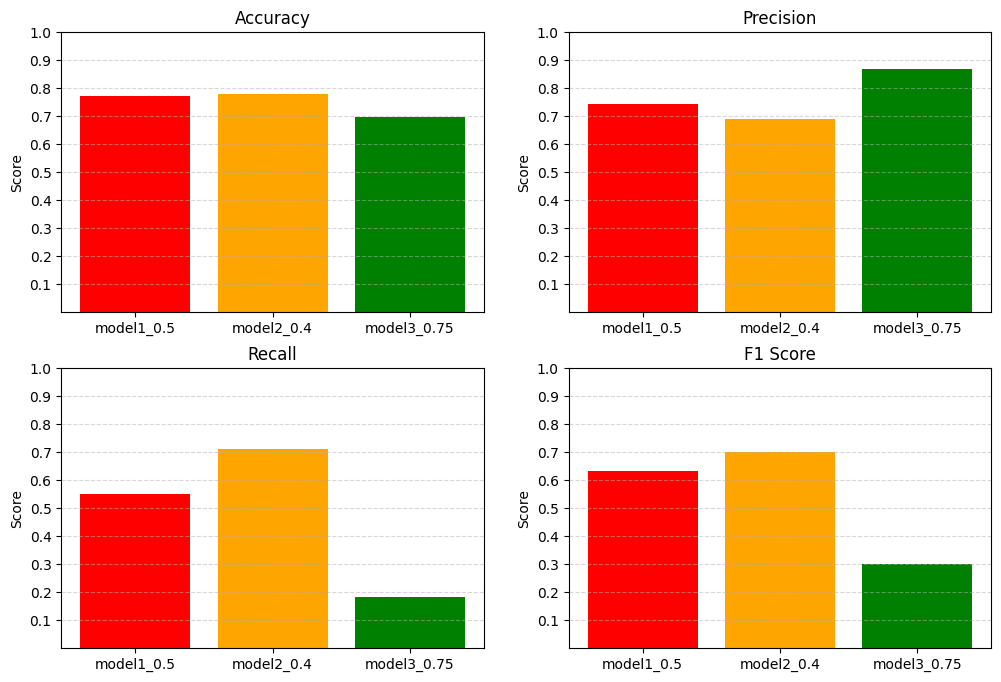

In [43]:
import matplotlib.pyplot as plt
model1_acc = metrics.accuracy_score(Y_train,Y_pred_train)
model2_acc = metrics.accuracy_score(Y_train,y_pred_train_2)
model3_acc = metrics.accuracy_score(Y_train,y_pred_train_3)

model1_pre = metrics.precision_score(Y_train,Y_pred_train)
model2_pre = metrics.precision_score(Y_train,y_pred_train_2)
model3_pre = metrics.precision_score(Y_train,y_pred_train_3)

model1_recall = metrics.recall_score(Y_train,Y_pred_train)
model2_recall = metrics.recall_score(Y_train,y_pred_train_2)
model3_recall = metrics.recall_score(Y_train,y_pred_train_3)

model1_f1 = metrics.f1_score(Y_train,Y_pred_train)
model2_f1 = metrics.f1_score(Y_train,y_pred_train_2)
model3_f1 = metrics.f1_score(Y_train,y_pred_train_3)
models =["model1_0.5","model2_0.4","model3_0.75"]

metrics_data = {
    "Accuracy": [model1_acc, model2_acc, model3_acc],
    "Precision": [model1_pre, model2_pre, model3_pre],
    "Recall": [model1_recall, model2_recall, model3_recall],
    "F1 Score": [model1_f1, model2_f1, model3_f1]
}
colors = ['red', 'orange', 'green']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, (metric_name, values) in enumerate(metrics_data.items()):
    bars = axes[i].bar(models, values, color=colors)
    axes[i].set_ylim(0, 1)
    axes[i].set_yticks([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])
    axes[i].set_title(metric_name)
    axes[i].set_ylabel('Score')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)




In [52]:
y_pred_test = model1.predict(X_test)
print(confusion_matrix(Y_test, y_pred_test))
print("Accuracy: ",metrics.accuracy_score(Y_test,y_pred_test))
print('Precision: ',metrics.precision_score(Y_test,y_pred_test))
print('Recall score: ',metrics.recall_score(Y_test,y_pred_test))
print('F1 score: ',metrics.f1_score(Y_test,y_pred_test))

[[100   7]
 [ 28  19]]
Accuracy:  0.7727272727272727
Precision:  0.7307692307692307
Recall score:  0.40425531914893614
F1 score:  0.5205479452054794
